# Step 1: Data Preparation & Cleaning

In [2]:
# Importing Dependency
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [3]:
# Load the data
df = pd.read_csv("/content/CLEANED_marketing_campaign_dataset.csv")

In [4]:
# DATA Cleaning:
# 1. Drop rows with missing values in our target columns
df = df.dropna(subset=['campaign_type', 'roi_ratio'])

# 2. Filter out campaign types with very low sample sizes (noise reduction)
min_samples = 30
df = df.groupby('campaign_type').filter(lambda x: len(x) > min_samples)

print(f"Unique Campaign Types identified: {df['campaign_type'].unique()}")

Unique Campaign Types identified: ['Search' 'Display' 'Social Media' 'Email' 'Influencer']


# Step 2: The ANOVA Test
**We use f_oneway from scipy.stats. The "F" in F-stat stands for Variance. It basically compares the variance between the groups to the variance within the groups**

In [5]:
# Create list of arrays for each group
groups = [group["roi_ratio"].values for name, group in df.groupby("campaign_type")]

# ASSUMPTION TESTING (Levene’s Test)
# We check if all campaign types have roughly the same "spread" (variance)
# levene_stat, levene_p = stats.levene(*groups)
# print(f"--- Step 1: Assumption Check ---")
# print(f"Levene’s Test P-Value: {levene_p:.4f}")
# if levene_p < 0.05:
#     print("Warning: Variances are NOT equal. Standard ANOVA may be inaccurate.")
#     # Professional Tip: If this happens, use 'Welch ANOVA' instead of 'f_oneway'
# else:
#     print("Success: Variances are equal. Proceeding to Standard ANOVA.\n")

# Perform One-Way ANOVA
f_stat, p_value = stats.f_oneway(*groups)

print(f"--- ANOVA Results ---")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value}")

if p_value < 0.05:
    print("Verdict: Statistically Significant. At least one campaign type performs differently.")
else:
    print("Verdict: Not Significant. All campaign types perform similarly.")

--- ANOVA Results ---
F-Statistic: 0.2594
P-Value: 0.9040406168242962
Verdict: Not Significant. All campaign types perform similarly.


# Step 3: Post-Hoc Analysis (The Tukey Test)

**ANOVA is a "Global Test". It tells there is a difference, but it doesn't tells which specific groups are different. For that, we use the Tukey HSD (Honestly Significant Difference) test.**

In [6]:
if p_value < 0.05:
    print("\n--- Tukey HSD Post-Hoc Test ---")
    tukey = pairwise_tukeyhsd(endog=df['roi_ratio'],     # Data
                             groups=df['campaign_type'], # Groups
                             alpha=0.05)                # Significance level
    print(tukey)

    # Plot the Tukey results
    tukey.plot_simultaneous()
    plt.show()

# Step 4: Visualizing Group Performance (Box Plots)




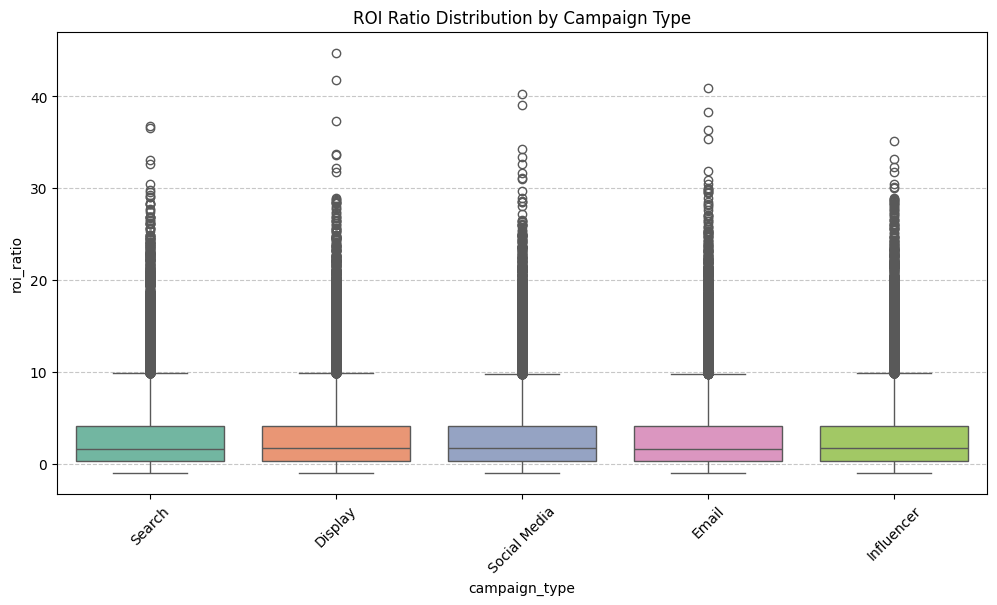

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='campaign_type', y='roi_ratio', data=df, palette="Set2", hue='campaign_type')
plt.title('ROI Ratio Distribution by Campaign Type')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

"The boxplot visualizes ROI distribution across campaign types using the five-number summary. The median ROI across most channels lies around 1.5–2, indicating moderate profitability. The interquartile ranges show that 50% of campaigns generate ROI between roughly 0.5 and 4. The presence of numerous high-value outliers suggests occasional extremely successful campaigns. The distribution is right-skewed, which is typical for marketing performance data where a small number of campaigns drive very high returns."

# Based on the ANOVA test results and the generated box plot, here are the key insights:

**ANOVA Verdict:** The ANOVA test yielded a P-Value of approximately 0.904. Since this P-Value is significantly higher than the typical significance level of 0.05, we conclude that there is no statistically significant difference in the average ROI ratio among the different campaign types.

**Interpretation:** This means that, based on this dataset, we cannot confidently say that any one campaign type (Search, Display, Social Media, Email, Influencer) performs significantly better or worse than the others in terms of Return on Investment.

**Visual Confirmation (Box Plot):** The box plot visually reinforces this conclusion. You can observe that the boxes (representing the interquartile range) and whiskers for all campaign types largely overlap. Their medians (the line inside each box) are also quite close, indicating similar central tendencies and distributions of ROI ratios across the different campaign types. There are some outliers, but they do not shift the overall conclusion of similar performance.

**In summary, the analysis suggests that all identified campaign types are performing similarly regarding ROI ratio, and there is no strong evidence to prioritize one over another based purely on these ROI metrics.**